In [ ]:
from ngsolve import *
from netgen.occ import unit_square, unit_cube
from netgen.read_gmsh import ReadGmsh
from ngsolve.webgui import Draw
from netgen.csg import *

# import geometries
mesh = ReadGmsh('meshes/ERMES_2.msh')

from ngsolve import *
from netgen.occ import unit_square, unit_cube
from netgen.read_gmsh import ReadGmsh
from ngsolve.webgui import Draw
from netgen.csg import *

# mesh.SetMaterial(1, "Coil")
# mesh.SetMaterial(2, "Vacuum")
# mesh.SetMaterial(3, "Tile")
# mesh.SetMaterial(4, "Pipe")
# mesh.SetMaterial(5, "Block")


# mesh.SetBCName(0, "CoilOut")
# mesh.SetBCName(1, "CoilIn")
# mesh.SetBCName(2, "VacuumSurface")

mesh = Mesh(mesh)

mesh.ngmesh.Save("meshes/ERMES_2.vol")

# Draw(mesh)

[0.99999994 0.99999994 1.         ... 1.         1.         0.99999994]


/home/wiera/anaconda3/envs/ngsolve-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


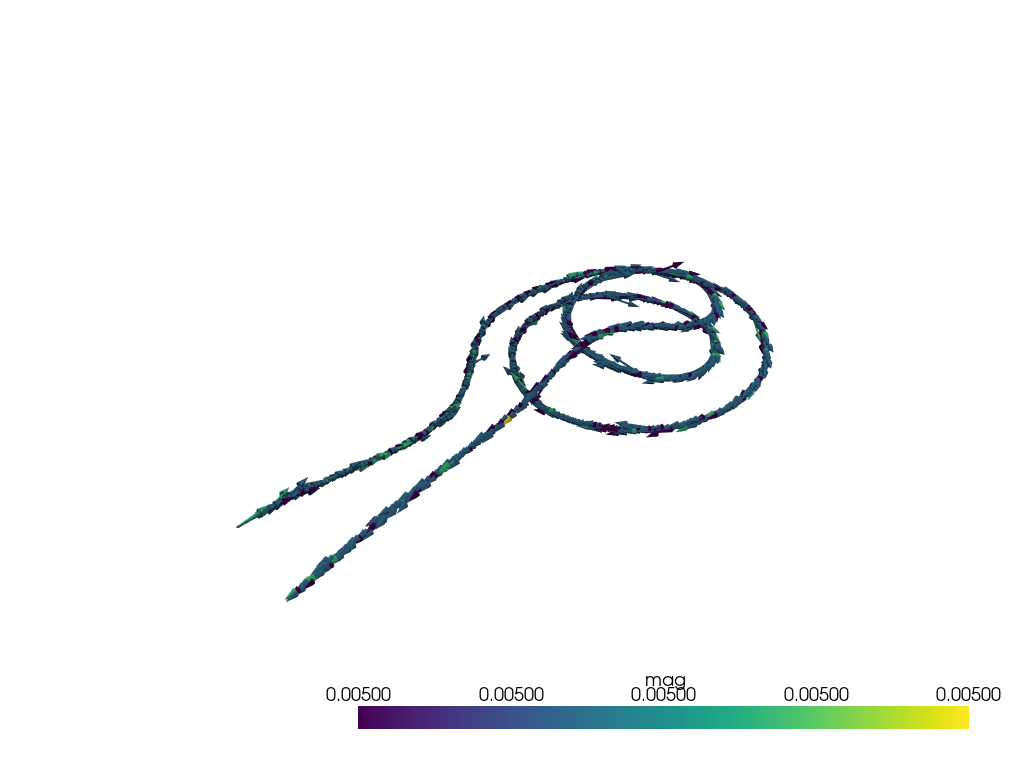

In [3]:
import pyvista as pv
import numpy as np

mesh = pv.read("meshes/centreline_coil.vtk")

centers = np.array(mesh.points)

# Compute tangents
tangents = np.gradient(centers, axis=0)
tangents /= np.linalg.norm(tangents, axis=1)[:, None]

# reverse tangent direction
tangents = -tangents
tangents[0] = tangents[1]

# check nans
nan_indices = np.isnan(tangents).any()
if np.any(nan_indices):
    print("NaN values found in tangents at indices:", np.where(nan_indices)[0])

# print tangent magnitude
tangent_magnitude = np.linalg.norm(tangents, axis=1)
print(tangent_magnitude)

plotter = pv.Plotter()
plotter.add_mesh(mesh, color="lightgray")
plotter.add_arrows(centers, tangents, mag=0.005)
plotter.show()

from scipy.spatial import cKDTree
tree = cKDTree(centers)

In [ ]:
#WORKS

from ngsolve import *
from netgen.occ import unit_square, unit_cube
from netgen.read_gmsh import ReadGmsh
from ngsolve.webgui import Draw
from netgen.csg import *

mesh = Mesh("meshes/ERMES_2.vol")
Vtangent = VectorH1(mesh, order=1, dim=1)
tau_gf = GridFunction(Vtangent)
# print(tau_gf.vec)

array = tau_gf.vec.FV().NumPy()

print(array.shape)

nodes = np.array(mesh.vertices)
print(nodes.shape)
n = nodes.shape[0]
vertices = mesh.vertices
for i, v in enumerate(vertices):
    point = np.array(v.point)
    # print(point)
    # print(type(point))
    # print(point.shape)
    _, idx = tree.query(point) # Closest point in coil centerline
    t = tangents[idx]
    # tangent_magnitude = np.linalg.norm(t)
    # print(t)
    # print(tangent_magnitude)

    if np.isnan(t).any():
        t = np.array([0.0, 0.0, 0.0])

    tau_gf.vec[i] = t[0]
    tau_gf.vec[n + i] = t[1]
    tau_gf.vec[2*n + i] = t[2]


tau_CF = CoefficientFunction(tau_gf)

tau_coil_only = mesh.MaterialCF({"Coil.*": tau_CF}, default=CF((0, 0, 0)))
# tau_gf.vec[1] = 1.0

mat_id = GridFunction(L2(mesh))
mat_mapping = {name: i+1 for i, name in enumerate(mesh.GetMaterials())}

mat_cf = CoefficientFunction([mat_mapping.get(mat, 0) for mat in mesh.GetMaterials()])
mat_id.Set(mat_cf)

# save it as vtk
# vtk = VTKOutput(ma=mesh,
#                 coefs=[tau_coil_only,mat_id],
#                 names=["Tangent","MaterialID"],
#                 filename="output/HIVE_coil/coil_tangents",
#                 subdivision=0)
# vtk.Do()

(213345,)
(71115,)


In [ ]:
from ngsolve import *
from netgen.occ import *
from ngsolve.webgui import Draw
from ngsolve import *
from netgen.geom2d import unit_square
from ngsolve.webgui import Draw
import math
from ngsolve.krylovspace import GMRes
import pyvista as pv
import numpy as np
from scipy.spatial import cKDTree

f = 101.3e3  # Frequency in Hz
I_coil = 1   # total current in amperes
mu0 = 4*math.pi*1e-7
omega = 2*math.pi*f # f Hz excitation


# Load mesh
mesh = Mesh("meshes/ERMES_2.vol")
print(mesh.GetMaterials())
coil_area = Integrate(1, mesh, definedon=mesh.Boundaries("CoilIn"))
print(coil_area)
# coil_area = Integrate(1, mesh, definedon=mesh.Boundaries("CoilOut")) 
# print(coil_area)
# J_mag = I_coil / coil_area * 1e-3  # Current density in A/m^2
J_mag = I_coil / coil_area  # Current density in A/m^2


# Define material parameters
sigma = {"Coil": 0.0, "Vacuum": 0.0, "Tile": 1e7, "Pipe": 1e4, "Block": 1e4}  # S/m
mu_r = {"Coil": 1.0, "Vacuum": 1.0, "Tile": 1.0, "Pipe": 1.0, "Block": 1.0}

mu_cf = mu0 * CoefficientFunction([mu_r.get(mat, 1.0) for mat in mesh.GetMaterials()])
sigma_cf = CoefficientFunction([sigma.get(mat, 0.0) for mat in mesh.GetMaterials()])

# fes = HCurl(mesh, order=1, complex=True, dirichlet="VacuumSurface", gradientdomains="Tile|Block|Pipe")
fes = HCurl(mesh, order=2, complex=True, dirichlet="VacuumSurface", nograds = False)
u = fes.TrialFunction()
v = fes.TestFunction()


a = BilinearForm(fes, symmetric=False, condense=True)
a += (1/mu_cf) * (curl(u) * curl(v) + (1e-8 / mu_cf) * u * v) * dx

# a += (1/mu_cf) * curl(u) * curl(v) * dx
a += (1j * omega * sigma_cf) * u * v * dx

# a += SymbolicBFI(1e-1*u*v)  # regularisation

coil_current_density = J_mag * tau_coil_only
f = LinearForm(fes)
f += coil_current_density * v * dx(mesh.Materials("Coil"), bonus_intorder=4)

a.Assemble()
f.Assemble()

A = GridFunction(fes)

# Preconditioner
# pre = a.mat.CreateSmoother(fes.FreeDofs())
pre = preconditioners.Local(a)
# pre = Preconditioner(a, type="direct", inverse="sparsecholesky")
# pre = a.mat.CreateJacobiPrecond()
# pre = Preconditioner(a, type="multigrid", flags = { "smoother" : "block" } )

# Apply GMRes directly
A.vec.data = GMRes(a.mat, f.vec, pre=pre, maxsteps=300, printrates=True, tol= 1e-9)

# solvers.BVP(bf=a, lf=f, gf=A, pre=pre, \
#                 solver=solvers.CGSolver, solver_flags={"plotrates": True, "tol" : 1e-10, "maxsteps": 300})


('Coil', 'Vacuum', 'Tile', 'Pipe', 'Block')
1.7077127401399054e-05
GMRes iteration 1, residual = 0.20453898133405926     
GMRes iteration 2, residual = 0.08272804222197484     
GMRes iteration 3, residual = 0.05558144421928481     
GMRes iteration 4, residual = 0.04538548351467614     
GMRes iteration 5, residual = 0.039836385650865266     
GMRes iteration 6, residual = 0.034604813255989575     
GMRes iteration 7, residual = 0.028705284680877977     
GMRes iteration 8, residual = 0.023252859433676935     
GMRes iteration 9, residual = 0.019372644410060116     
GMRes iteration 10, residual = 0.0161354837653086     
GMRes iteration 11, residual = 0.01340552956590356     
GMRes iteration 12, residual = 0.010842623765644972     
GMRes iteration 13, residual = 0.008658514732627184     
GMRes iteration 14, residual = 0.006907565210514464     
GMRes iteration 15, residual = 0.0055699940160368     
GMRes iteration 16, residual = 0.004705077643601307     
GMRes iteration 17, residual = 0.004102

In [ ]:
B = curl(A)
J = -1j*omega*sigma_cf * A


JJ  = J * Conj(J)
q = 0.5 * JJ.real / sigma_cf


# q = omega ** 2 * sigma_cf * A.real ** 2

# Project to L2 space for integration and visualization
# Q = L2(mesh, dim=3)
# hf = GridFunction(Q)
# hf.Set(J.real)

Q = L2(mesh, dim=3)
hf = GridFunction(Q)
hf.Set(J.real)

mat_id = GridFunction(L2(mesh))
mat_mapping = {name: i+1 for i, name in enumerate(mesh.GetMaterials())}

mat_cf = CoefficientFunction([mat_mapping.get(mat, 0) for mat in mesh.GetMaterials()])
mat_id.Set(mat_cf)

# Save mesh + field + material ID
vtk = VTKOutput(ma=mesh,
                coefs=[hf, mat_id],
                names=["J", "MaterialID"],
                filename="output/result_HIVE_coil",
                subdivision=0)
vtk.Do()

'output/result_HIVE_coil'

In [ ]:
E = -1j*omega * A
EE = sigma_cf * E * Conj(E)
q = 0.5 * EE.real


# q = omega ** 2 * sigma_cf * A.real ** 2

# Project to L2 space for integration and visualization
# Q = L2(mesh, dim=3)
# hf = GridFunction(Q)
# hf.Set(J.real)

Q = H1(mesh, order=3, dim=1)
hf = GridFunction(Q)
hf.Set(q.real)

print(len(hf.vec))

mat_id = GridFunction(H1(mesh, order=1, dim=1))
mat_mapping = {name: i+1 for i, name in enumerate(mesh.GetMaterials())}

mat_cf = CoefficientFunction([mat_mapping.get(mat, 0) for mat in mesh.GetMaterials()])
mat_id.Set(mat_cf)

print(len(mat_id.vec))

# Save mesh + field + material ID
vtk = VTKOutput(ma=mesh,
                coefs=[hf, mat_id],
                names=["J", "MaterialID"],
                filename="output/result_HIVE_coil2",
                subdivision=0)
vtk.Do()

1876812
71115


'output/result_HIVE_coil2'

In [ ]:
import meshio
import numpy as np
import pyvista as pv

E = -1j*omega * A
EE = sigma_cf * E * Conj(E)
q = 0.5 * EE.real


# J = sigma_cf * E
# q = InnerProduct(J, E).real
# J = -1j*omega*sigma * A


Q = H1(mesh, order=1, dim=1)
hf = GridFunction(Q)
hf.Set(q.real)

print(len(hf.vec))

mat_id = GridFunction(H1(mesh, order=1, dim=1))
mat_mapping = {name: i+1 for i, name in enumerate(mesh.GetMaterials())}

mat_cf = CoefficientFunction([mat_mapping.get(mat, 0) for mat in mesh.GetMaterials()])
mat_id.Set(mat_cf)

print(len(mat_id.vec))

# Read the VTK file
mesh1 = pv.read("ERMES_2.msh")

mesh1['J'] = np.array(hf.vec.data)
mesh1['MaterialID'] = np.array(mat_id.vec.data)
# # Save to a new VTK file
mesh1.save("output/HIVE_coil/result_HIVE_coil.vtu")

71115
71115


In [ ]:
import pyvista as pv
import numpy as np

# Read the VTK file
sol_ref= pv.read("output/HIVE_coil/compare/HIVE_coil_ref.vtk")
sol= pv.read("output/HIVE_coil/compare/HIVE_coil_NGSolve.vtk")

points = sol_ref.points
data_ref = sol_ref['Joule_heating']

In [21]:
E = -1j * omega * A
voltage = Integrate(E * tau_coil_only, mesh, definedon=mesh.Materials("coil"))

In [1]:
import pyvista as pv

mesh = pv.read("meshes/mesh_comsol2.nas")

print(mesh)

UnstructuredGrid (0x76d9616dd3c0)
  N Cells:    1129380
  N Points:   207878
  X Bounds:   -2.500e-01, 2.500e-01
  Y Bounds:   -2.500e-01, 2.500e-01
  Z Bounds:   -2.000e-01, 2.000e-01
  N Arrays:   1


In [2]:
mesh.save("meshes/mesh_comsol2.vtu")

In [4]:
import meshio

mesh = meshio.read("meshes/mesh_comsol.nas")

In [ ]:
meshio.write("meshes/mesh.mesh", mesh)